In [2]:
#task 4
from sklearn.datasets import load_iris
import pandas as pd

# Load the Iris dataset
df=pd.read_csv('/content/Iris.csv')
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

# Display the first few rows
print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


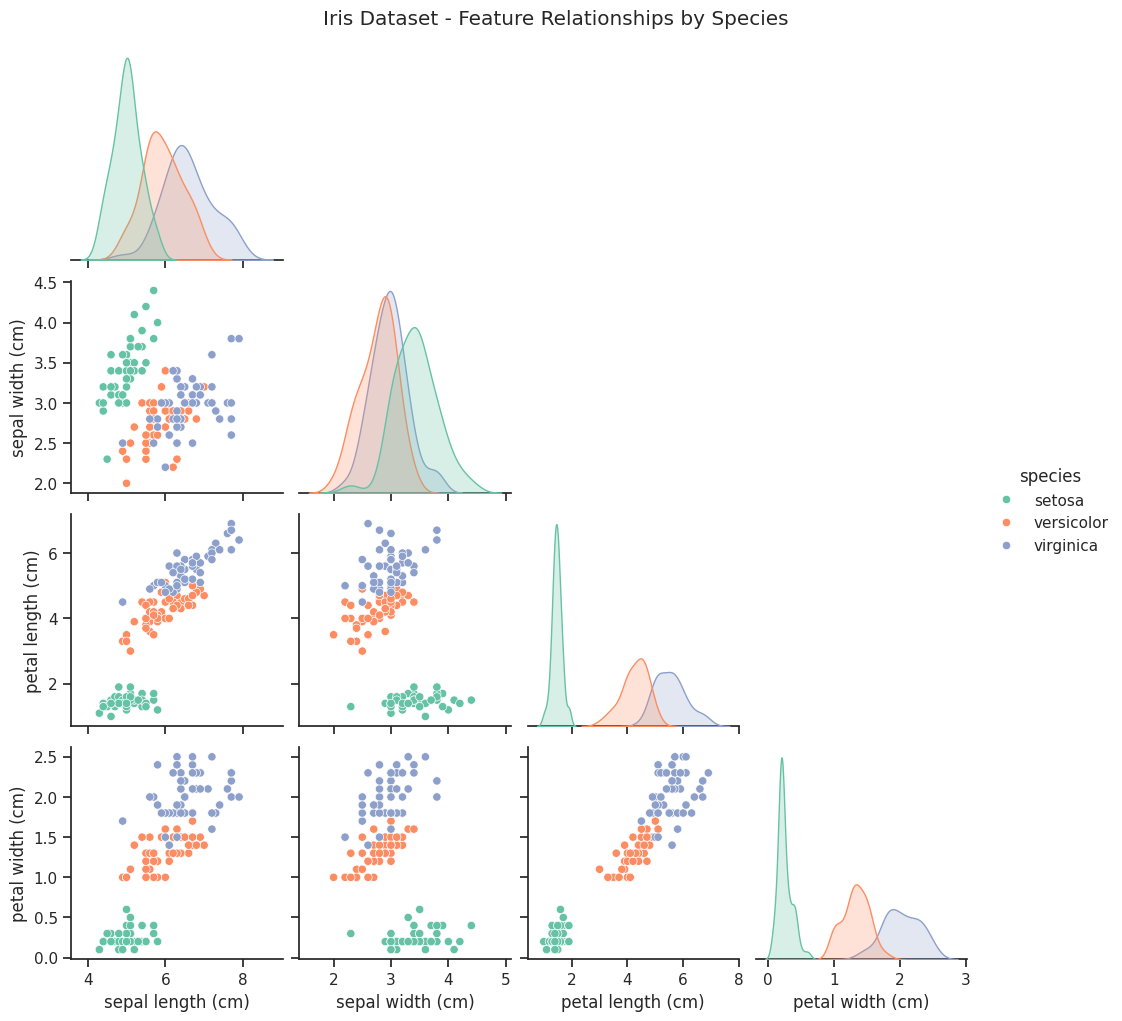

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn theme
sns.set(style="ticks")

# Create a pairplot with a title
pairplot = sns.pairplot(df, hue='species', palette='Set2', corner=True)
pairplot.fig.suptitle("Iris Dataset - Feature Relationships by Species", y=1.02)
plt.show()


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into features and target
X = df.drop('species', axis=1)
y = df['species']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create and train the KNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')


Accuracy: 1.00


In [8]:
from sklearn.metrics import classification_report, confusion_matrix

# Print the classification report
print(classification_report(y_test, y_pred))

# Print the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [9]:
import joblib

# Save the model and the scaler
joblib.dump(knn, 'knn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [16]:
!pip install pyngrok
!pip install flask pyngrok
!ngrok config add-authtoken 2wr4PkrxiSWymlX0ajgFBhLLz4s_5wmp4N4m6dxsjNAY81Tyg


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from flask import Flask
from pyngrok import ngrok

# Create Flask app
app = Flask(__name__)

@app.route('/')
def home():
    return "✅ Flask app is working on Google Colab via ngrok!"

# Open a tunnel on port 5000
public_url = ngrok.connect(5000)
print("🔗 Public URL:", public_url)

# Start the Flask app
app.run(port=5000)


🔗 Public URL: NgrokTunnel: "https://06eb-34-46-89-200.ngrok-free.app" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [09/May/2025 13:15:42] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [09/May/2025 13:15:42] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [09/May/2025 13:16:55] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [09/May/2025 13:20:17] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [09/May/2025 13:24:14] "GET / HTTP/1.1" 200 -
